# GBM calibration & Monte Carlo — period 2008–2009

**Period file:** one notebook = one sample window. This file covers **2008-01-01 → 2009-12-31**.

| Role | Ticker |
|------|--------|
| Primary | **SPY** |
| Secondary | AAPL |
| Secondary | MSFT |

**Rolling rule (important):** at each update point, re-estimate \(\hat\mu, \hat\sigma\) from the current lookback window only, then use those params for the **next** Monte Carlo segment. Parameters are **not** held fixed from day 1 (unless rolling = `none`). See `ROLLING_CALIBRATION.md`.

**Contents**
1. Historical adjusted-close trends
2. Strike prices for this window
3. GBM formulas + rolling calibration design
4. Interactive calibration (lookback + rolling) + **Reestimate**
5. Interactive Monte Carlo with **true rolling** params — six graphs


## 0. Setup


In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, Markdown, clear_output
import ipywidgets as widgets

%matplotlib inline
plt.rcParams.update({
    "figure.dpi": 110,
    "axes.grid": True,
    "grid.alpha": 0.25,
    "axes.spines.top": False,
    "axes.spines.right": False,
})

DATA = Path("..") / "data"
PERIOD_START = pd.Timestamp("2008-01-01")
PERIOD_END = pd.Timestamp("2009-12-31")
TICKERS = ["AAPL", "MSFT", "SPY"]  # SPY is primary
N_DAYS = 252
COLORS = {"AAPL": "#1f77b4", "MSFT": "#ff7f0e", "SPY": "#2ca02c"}

WINDOW_OPTIONS = {
    "3 months": pd.DateOffset(months=3),
    "6 months": pd.DateOffset(months=6),
    "1 year": pd.DateOffset(years=1),
    "2 years": pd.DateOffset(years=2),
    "5 years": pd.DateOffset(years=5),
}
ROLLING_OPTIONS = ["daily", "monthly", "none"]

prices = pd.read_csv(DATA / "equity" / "prices_clean.csv", parse_dates=["Date"]).set_index("Date").sort_index()
period_prices = prices.loc[PERIOD_START:PERIOD_END, TICKERS].copy()
log_returns_all = np.log(prices[TICKERS]).diff()

# Filled by Reestimate
rolling = {}
cal_meta = {}  # window_label, rolling_mode

print(f"Price sample: {prices.index.min().date()} → {prices.index.max().date()}")
print(
    f"Period rows: {len(period_prices)} trading days "
    f"({period_prices.index.min().date()} → {period_prices.index.max().date()})"
)
period_prices.head()


Price sample: 2003-12-01 → 2020-12-31
Period rows: 505 trading days (2008-01-02 → 2009-12-31)


,AAPL,MSFT,SPY
Date,,,
2008-01-02,5.891123,25.581263,144.508517
2008-01-03,5.893844,25.690214,144.507950
2008-01-04,5.443937,24.971151,140.960431
2008-01-07,5.371069,25.138201,141.416348
2008-01-08,5.177862,24.295662,138.868473


## 1. Stock price trends (2008–2009)

Adjusted close for AAPL, MSFT, and SPY (primary) over the period.


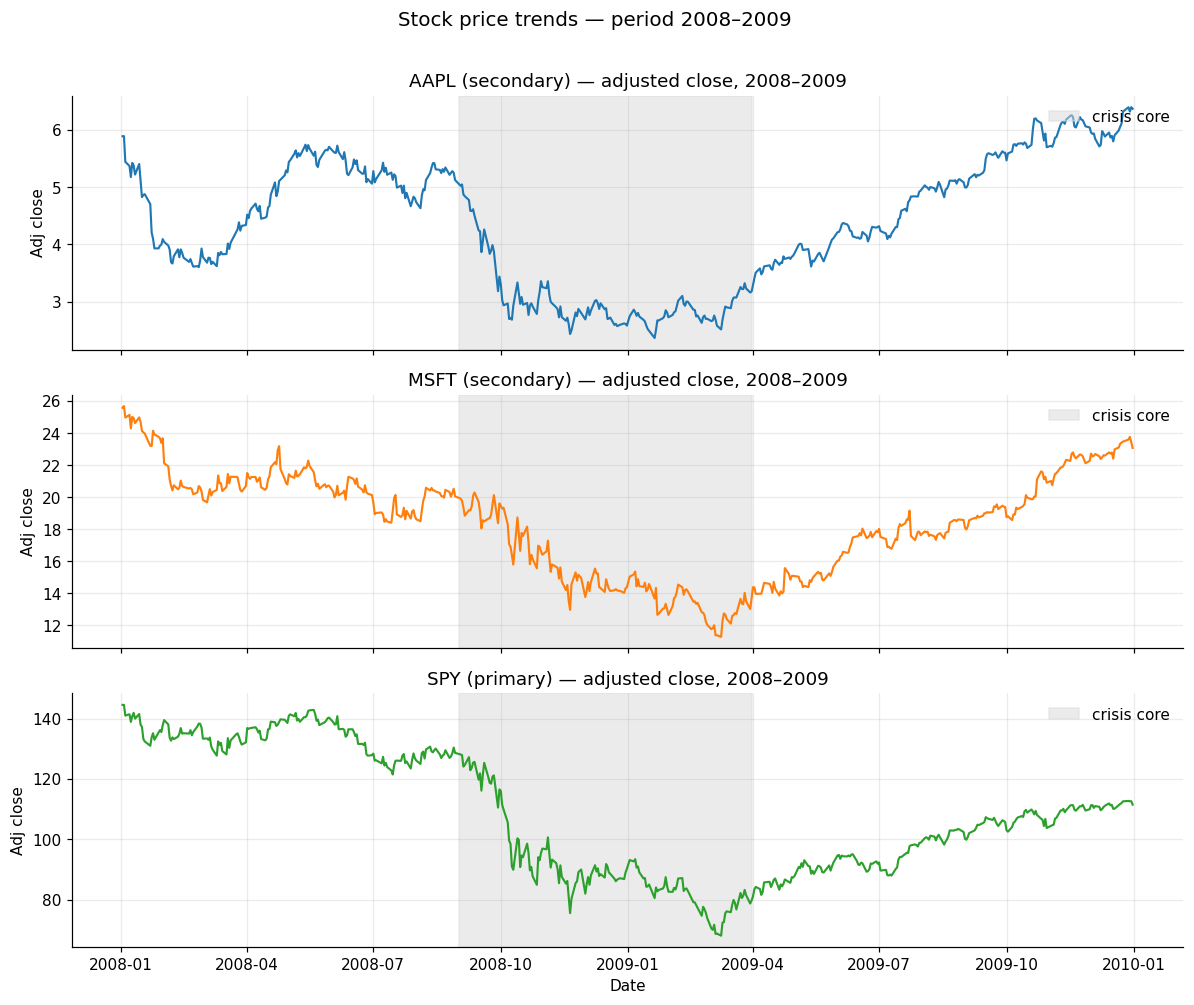

,count,mean,min,max
AAPL,505.0,4.3658,2.3644,6.3991
MSFT,505.0,18.3679,11.2838,25.6902
SPY,505.0,108.5902,68.1308,144.5085


In [2]:
fig, axes = plt.subplots(3, 1, figsize=(11, 9), sharex=True)

for ax, ticker in zip(axes, TICKERS):
    s = period_prices[ticker].dropna()
    ax.plot(s.index, s.values, color=COLORS[ticker], lw=1.4)
    role = "primary" if ticker == "SPY" else "secondary"
    ax.set_ylabel("Adj close")
    ax.set_title(f"{ticker} ({role}) — adjusted close, 2008–2009")

    ax.axvspan(
        pd.Timestamp("2008-09-01"),
        pd.Timestamp("2009-03-31"),
        color="0.85",
        alpha=0.5,
        label="crisis core",
    )
    ax.legend(loc="upper right", frameon=False)
axes[-1].set_xlabel("Date")
fig.suptitle("Stock price trends — period 2008–2009", fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

display(period_prices.describe().T[["count", "mean", "min", "max"]].round(4))


## 2. Strike prices in this period

Unique strikes \(K\) from the processed American options panels (`*_options_panel.csv`), filtered to quotes with `trading_date` inside **2008-01-01 → 2009-12-31**.

> **Note:** AAPL strikes are on the **option/contract scale** (pre-split style), while equity adj closes are split-adjusted — do not mix them without a scale check.


In [3]:
for ticker in TICKERS:
    path = DATA / "options" / "processed" / f"{ticker}_options_panel.csv"
    opt = pd.read_csv(path, usecols=["trading_date", "K"], parse_dates=["trading_date"])
    m = (opt["trading_date"] >= PERIOD_START) & (opt["trading_date"] <= PERIOD_END)
    sub = opt.loc[m]
    uniq = np.sort(sub["K"].dropna().unique())
    dmin, dmax = sub["trading_date"].min(), sub["trading_date"].max()
    display(Markdown(
        f"### {ticker} — {len(uniq)} unique strikes "
        f"(options quotes {dmin.date() if pd.notna(dmin) else 'n/a'} → "
        f"{dmax.date() if pd.notna(dmax) else 'n/a'})"
    ))
    print("Strikes K:", ", ".join(f"{x:g}" for x in uniq))
    display(pd.DataFrame({"K": uniq}).T)


### AAPL — 29 unique strikes (options quotes 2008-01-02 → 2009-12-30)

Strikes K: 75, 80, 85, 90, 95, 100, 105, 110, 115, 120, 125, 130, 135, 140, 145, 150, 155, 160, 165, 170, 175, 180, 185, 190, 195, 200, 210, 220, 230


,0,1,2,3,4,5,6,7,8,9,...,19,20,21,22,23,24,25,26,27,28
K,75.0,80.0,85.0,90.0,95.0,100.0,105.0,110.0,115.0,120.0,...,170.0,175.0,180.0,185.0,190.0,195.0,200.0,210.0,220.0,230.0


### MSFT — 27 unique strikes (options quotes 2008-01-02 → 2009-12-28)

Strikes K: 14, 15, 16, 17, 17.5, 18, 19, 20, 21, 22, 22.5, 23, 24, 25, 26, 27, 27.5, 28, 29, 30, 31, 32, 32.5, 33, 34, 35, 37.5


,0,1,2,3,4,5,6,7,8,9,...,17,18,19,20,21,22,23,24,25,26
K,14.0,15.0,16.0,17.0,17.5,18.0,19.0,20.0,21.0,22.0,...,28.0,29.0,30.0,31.0,32.0,32.5,33.0,34.0,35.0,37.5


### SPY — 20 unique strikes (options quotes 2008-01-04 → 2009-12-29)

Strikes K: 110, 111, 112, 113, 114, 115, 116, 117, 118, 119, 120, 121, 122, 123, 124, 125, 126, 127, 128, 129


,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19
K,110.0,111.0,112.0,113.0,114.0,115.0,116.0,117.0,118.0,119.0,120.0,121.0,122.0,123.0,124.0,125.0,126.0,127.0,128.0,129.0


## 3. Estimation formulas (GBM)

Under GBM,

$$dS_t = \mu S_t\, dt + \sigma S_t\, dW_t$$

with discrete simulation

$$S_{t+\Delta t} = S_t \exp\Big(\big(\mu - \tfrac{1}{2}\sigma^2\big)\Delta t + \sigma\sqrt{\Delta t}\, Z\Big),\quad Z\sim N(0,1).$$

### Parameter estimators (inside each window)

| Parameter | Estimator (daily data, \(N=252\)) |
|-----------|-----------------------------------|
| \(\hat\mu\) | \(\bar r \times 252\) |
| \(\hat\sigma\) | \(s_r \times \sqrt{252}\) |
| \(r_t\) | \(\ln(S_t / S_{t-1})\) |

### True rolling-window design

1. At update date \(t_u\), form the lookback window \((t_u - W,\, t_u]\) and re-estimate \(\hat\mu(t_u),\hat\sigma(t_u)\).
2. Use those parameters for Monte Carlo steps from \(t_u\) until the next update \(t_{u+1}\).
3. Slide the window forward and repeat.

| Rolling mode | Update frequency |
|--------------|------------------|
| `daily` | every trading day — params at \(t\) drive step \(t \to t+1\) |
| `monthly` | each month-end (+ period start) — params held until next update |
| `none` | period start only — fixed params for the whole period |

Lookback \(W\): 3 months · 6 months · 1 year · 2 years · 5 years.


## 4. Interactive calibration (lookback slider + rolling slider + Reestimate) — 2008–2009

Use the **Lookback** and **Rolling** sliders below, then click **Reestimate**.


In [ ]:
def estimate_mu_sigma(log_rets: pd.Series):
    x = log_rets.dropna()
    n = int(x.shape[0])
    if n < 2:
        return np.nan, np.nan, n
    return float(x.mean() * N_DAYS), float(x.std(ddof=1) * np.sqrt(N_DAYS)), n


def _slice_window(rets: pd.Series, end: pd.Timestamp, offset: pd.DateOffset) -> pd.Series:
    start = end - offset
    return rets.loc[(rets.index > start) & (rets.index <= end)]


def calibrate_ticker(ticker: str, window_label: str, rolling_mode: str) -> pd.DataFrame:
    """Calibration table at each update date: date, window_*, n_days, mu, sigma."""
    rets = log_returns_all[ticker].dropna()
    offset = WINDOW_OPTIONS[window_label]
    rows = []

    if rolling_mode == "daily":
        dates = rets.loc[(rets.index >= PERIOD_START) & (rets.index <= PERIOD_END)].index
        update_dates = dates
    elif rolling_mode == "monthly":
        t0 = period_prices[ticker].dropna().index[0]
        month_ends = pd.date_range(PERIOD_START, PERIOD_END, freq="ME")
        update_dates = pd.DatetimeIndex([t0]).append(month_ends).unique().sort_values()
    else:  # none
        t0 = period_prices[ticker].dropna().index[0]
        update_dates = pd.DatetimeIndex([t0])

    for t_u in update_dates:
        window = _slice_window(rets, pd.Timestamp(t_u), offset)
        mu, sigma, n = estimate_mu_sigma(window)
        if n < 2:
            continue
        rows.append({
            "date": pd.Timestamp(t_u),
            "window_start": window.index.min(),
            "window_end": window.index.max(),
            "n_days": n,
            "mu": mu,
            "sigma": sigma,
        })
    return pd.DataFrame(rows)


def param_schedule_for_steps(ticker: str, cal_table: pd.DataFrame):
    """
    For each step dates[i] -> dates[i+1], use latest calibration with date <= dates[i].
    Returns dates, mu_step (len n_steps), sigma_step (len n_steps), S0.
    """
    hist = period_prices[ticker].dropna()
    dates = hist.index
    n_steps = len(dates) - 1
    cal = cal_table.sort_values("date").reset_index(drop=True)
    cal_dates = pd.to_datetime(cal["date"]).to_numpy()
    mu_arr = cal["mu"].to_numpy(dtype=float)
    sig_arr = cal["sigma"].to_numpy(dtype=float)

    mu_step = np.empty(n_steps, dtype=float)
    sig_step = np.empty(n_steps, dtype=float)
    for i in range(n_steps):
        # params known at dates[i] = latest update on or before dates[i]
        idx = np.searchsorted(cal_dates, np.datetime64(dates[i]), side="right") - 1
        if idx < 0:
            idx = 0
        mu_step[i] = mu_arr[idx]
        sig_step[i] = sig_arr[idx]
    return dates, mu_step, sig_step, float(hist.iloc[0]), hist


def plot_rolling_paths(rolling_dict: dict, window_label: str, rolling_mode: str):
    fig, axes = plt.subplots(2, 1, figsize=(11, 6), sharex=True)
    for t in TICKERS:
        r = rolling_dict[t]
        x = pd.to_datetime(r["date"])
        mark = "o" if len(r) < 40 else None
        axes[0].plot(x, r["mu"], lw=1.2, label=t, color=COLORS[t], marker=mark, ms=3)
        axes[1].plot(x, r["sigma"], lw=1.2, label=t, color=COLORS[t], marker=mark, ms=3)
    axes[0].axhline(0, color="0.5", lw=0.8)
    axes[0].set_ylabel("μ̂ (annual)")
    axes[0].set_title(f"Rolling drift updates — {rolling_mode}, lookback {window_label}")
    axes[0].legend(frameon=False, ncol=3)
    axes[1].set_ylabel("σ̂ (annual)")
    axes[1].set_title(f"Rolling volatility updates — {rolling_mode}, lookback {window_label}")
    axes[1].set_xlabel("Date")
    axes[1].legend(frameon=False, ncol=3)
    plt.tight_layout()
    plt.show()


cal_out = widgets.Output()
window_slider = widgets.SelectionSlider(
    options=list(WINDOW_OPTIONS.keys()),
    value="1 year",
    description="Lookback",
    continuous_update=False,
    style={"description_width": "70px"},
    layout=widgets.Layout(width="420px"),
)
rolling_slider = widgets.SelectionSlider(
    options=ROLLING_OPTIONS,
    value="daily",
    description="Rolling",
    continuous_update=False,
    style={"description_width": "70px"},
    layout=widgets.Layout(width="420px"),
)
btn_reestimate = widgets.Button(description="Reestimate", button_style="primary", icon="refresh")


def reestimate(_=None):
    global rolling, cal_meta
    window_label = window_slider.value
    rolling_mode = rolling_slider.value
    rolling = {t: calibrate_ticker(t, window_label, rolling_mode) for t in TICKERS}
    cal_meta = {"window_label": window_label, "rolling_mode": rolling_mode}

    with cal_out:
        clear_output(wait=True)
        display(Markdown(
            f"**True rolling calibration:** lookback = `{window_label}`, mode = `{rolling_mode}`.<br>"
            f"Each update re-estimates \(\hat\mu, \hat\sigma\) from the current window; "
            f"MC uses those params until the next update."
        ))
        # show first / last update for each ticker
        rows = []
        for t in TICKERS:
            r = rolling[t]
            rows.append({
                "ticker": t,
                "n_updates": len(r),
                "first_update": pd.Timestamp(r.iloc[0]["date"]).date(),
                "last_update": pd.Timestamp(r.iloc[-1]["date"]).date(),
                "first μ̂": r.iloc[0]["mu"],
                "first σ̂": r.iloc[0]["sigma"],
                "last μ̂": r.iloc[-1]["mu"],
                "last σ̂": r.iloc[-1]["sigma"],
            })
        summary = pd.DataFrame(rows).set_index("ticker")
        display(summary.style.format({
            "first μ̂": "{:.4f}", "first σ̂": "{:.4f}",
            "last μ̂": "{:.4f}", "last σ̂": "{:.4f}",
        }))
        plot_rolling_paths(rolling, window_label, rolling_mode)
        if "mc_out" in globals():
            render_monte_carlo()


btn_reestimate.on_click(reestimate)
display(widgets.VBox([
    widgets.HTML(
        "<b>SLIDERS ARE HERE — Choose lookback + rolling mode, then Reestimate</b><br>"
        "<span style='color:#444'>MC below will use time-varying params (true rolling), not fixed day-1 params.</span>"
    ),
    window_slider,
    rolling_slider,
    btn_reestimate,
    cal_out,
]))
reestimate()


## 5. Interactive Monte Carlo (true rolling parameters)

For **each** of AAPL, MSFT, and SPY:

| Graph | What you see |
|-------|----------------|
| **Left** | Monte Carlo paths; at each step, \(\mu_t,\sigma_t\) come from the latest rolling update |
| **Right** | Expected path (MC mean) vs historical adj close over 2008–2009 |

**Start** / **Restart** redraw randomness. After changing sliders in §4, click **Reestimate**, then **Start** again.


In [ ]:
def simulate_gbm_rolling(mu_step, sigma_step, S0, n_paths, seed):
    """
    True rolling MC: step i uses mu_step[i], sigma_step[i] (re-estimated schedule).
    Returns paths with shape (n_paths, n_steps+1).
    """
    rng = np.random.default_rng(seed)
    n_steps = len(mu_step)
    dt = 1.0 / N_DAYS
    paths = np.empty((n_paths, n_steps + 1), dtype=float)
    paths[:, 0] = S0
    for i in range(n_steps):
        mu = mu_step[i]
        sigma = sigma_step[i]
        z = rng.standard_normal(n_paths)
        paths[:, i + 1] = paths[:, i] * np.exp(
            (mu - 0.5 * sigma**2) * dt + sigma * np.sqrt(dt) * z
        )
    return paths


def make_ticker_panel(ticker: str, n_paths: int = 80):
    dates, mu_step, sig_step, S0, hist = param_schedule_for_steps(ticker, rolling[ticker])
    state = {"seed": 42}
    mode = cal_meta.get("rolling_mode", "?")
    win = cal_meta.get("window_label", "?")

    out = widgets.Output()
    btn_start = widgets.Button(description="Start", button_style="success", icon="play")
    btn_restart = widgets.Button(description="Restart", button_style="warning", icon="refresh")
    info = widgets.HTML(
        value=(
            f"<b>{ticker}</b> — true rolling MC | lookback={win}, mode={mode} | "
            f"S₀={S0:.4f}, steps={len(mu_step)}, paths={n_paths} | "
            f"μ̂ range [{mu_step.min():.4f}, {mu_step.max():.4f}], "
            f"σ̂ range [{sig_step.min():.4f}, {sig_step.max():.4f}]"
        )
    )

    def run(new_seed: bool = False):
        if new_seed:
            state["seed"] = int(np.random.default_rng().integers(0, 1_000_000_000))
        with out:
            clear_output(wait=True)
            # refresh schedule from latest rolling tables
            dates_now, mu_now, sig_now, S0_now, hist_now = param_schedule_for_steps(
                ticker, rolling[ticker]
            )
            paths = simulate_gbm_rolling(
                mu_now, sig_now, S0_now, n_paths=n_paths, seed=state["seed"]
            )
            expected = paths.mean(axis=0)

            fig, axes = plt.subplots(1, 2, figsize=(12.5, 4.2))
            axes[0].plot(dates_now, paths.T, color=COLORS[ticker], alpha=0.12, lw=0.7)
            axes[0].plot(dates_now, expected, color="black", lw=2.2, label="expected path (MC mean)")
            axes[0].set_title(f"{ticker}: rolling-param Monte Carlo")
            axes[0].set_ylabel("price")
            axes[0].legend(loc="best", frameon=False)

            axes[1].plot(dates_now, hist_now.values, color=COLORS[ticker], lw=1.8, label="historical adj close")
            axes[1].plot(dates_now, expected, color="black", lw=2.0, ls="--", label="expected path (MC mean)")
            axes[1].set_title(f"{ticker}: expected rolling MC path vs history")
            axes[1].set_ylabel("price")
            axes[1].legend(loc="best", frameon=False)

            for ax in axes:
                ax.set_xlabel("date")
            fig.suptitle(
                f"{ticker}  |  seed={state['seed']}  |  {cal_meta.get('rolling_mode')} / {cal_meta.get('window_label')}",
                fontsize=11,
                y=1.02,
            )
            plt.tight_layout()
            plt.show()

            rmse = float(np.sqrt(np.mean((expected - hist_now.values) ** 2)))
            print(
                f"RMSE(expected vs historical) = {rmse:.4f}   |   seed = {state['seed']}   |   "
                f"updates used = {len(rolling[ticker])}"
            )

    btn_start.on_click(lambda _: run(new_seed=False))
    btn_restart.on_click(lambda _: run(new_seed=True))
    return widgets.VBox([info, widgets.HBox([btn_start, btn_restart]), out])


mc_out = widgets.Output()


def render_monte_carlo():
    with mc_out:
        clear_output(wait=True)
        if not rolling:
            display(Markdown("Run **Reestimate** in §4 first."))
            return
        display(Markdown(
            "### Six interactive graphs — **true rolling** params "
            "(re-estimated at each update, then used for the next segment)"
        ))
        for ticker in TICKERS:
            role = "primary" if ticker == "SPY" else "secondary"
            display(Markdown(f"#### {ticker} ({role})"))
            display(make_ticker_panel(ticker))


display(mc_out)
render_monte_carlo()


Output()

## 6. How to read the six graphs

1. **AAPL — Monte Carlo:** paths simulated with **time-varying** \((\mu_t,\sigma_t)\).
2. **AAPL — expected vs history:** MC mean path vs real prices.
3–6. Same for MSFT and SPY (primary).

Workflow: set lookback + rolling → **Reestimate** → **Start**. **Restart** only changes the random seed.
